#CS210 Project
Can Sağdıç - 30580

##Introduction
In 1912, well-known financier J.P. Morgan said "Gold is money, everything else is credit." implying that gold is the only commodity the value of which is not dependant on third parties.

In this project I aim to find out the prices of gold, one of the oldest and most stable commodities, has any effects on the prices of cryptocurrencies which emerged as modern, independent, decentralized investment options in the previous decades. (I have updated my step 2 according to the instructions given in May 10th)


In [ ]:
#necessary libraries
from os.path import join
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from google.colab import drive

drive.mount("/content/drive", force_remount=True)
path_prefix = "/content/drive/My Drive"

Mounted at /content/drive


##First Data Set

This is the 2019-2024 US Stock Market Data which is given to us. From this dataset, I am using the gold price data.

In [ ]:
filename = "Stock Market Dataset.csv"
StockMarket_data = pd.read_csv(join(path_prefix, filename))

#to remove the commas from the gold price data
StockMarket_data['Gold_Price'] = StockMarket_data['Gold_Price'].str.replace(',', '').astype(float)
StockMarket_data

,Unnamed: 0,Date,Natural_Gas_Price,Natural_Gas_Vol.,Crude_oil_Price,Crude_oil_Vol.,Copper_Price,Copper_Vol.,Bitcoin_Price,Bitcoin_Vol.,...,Berkshire_Price,Berkshire_Vol.,Netflix_Price,Netflix_Vol.,Amazon_Price,Amazon_Vol.,Meta_Price,Meta_Vol.,Gold_Price,Gold_Vol.
0,0,02-02-2024,2.079,NaN,72.28,NaN,3.8215,NaN,"43,194.70",42650.0,...,"5,89,498",10580.0,564.64,4030000.0,171.81,117220000.0,474.99,84710000.0,2053.7,NaN
1,1,01-02-2024,2.050,161340.0,73.82,577940.0,3.8535,NaN,"43,081.40",47690.0,...,"5,81,600",9780.0,567.51,3150000.0,159.28,66360000.0,394.78,25140000.0,2071.1,260920.0
2,2,31-01-2024,2.100,142860.0,75.85,344490.0,3.9060,NaN,"42,580.50",56480.0,...,"5,78,020",9720.0,564.11,4830000.0,155.20,49690000.0,390.14,20010000.0,2067.4,238370.0
3,3,30-01-2024,2.077,139750.0,77.82,347240.0,3.9110,NaN,"42,946.20",55130.0,...,"5,84,680",9750.0,562.85,6120000.0,159.00,42290000.0,400.06,18610000.0,2050.9,214590.0
4,4,29-01-2024,2.490,3590.0,76.78,331930.0,3.8790,NaN,"43,299.80",45230.0,...,"5,78,800",13850.0,575.79,6880000.0,161.26,42840000.0,401.02,17790000.0,2034.9,1780.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1238,1238,08-02-2019,2.583,147880.0,52.72,621000.0,2.8140,270.0,"3,661.70",699230.0,...,"3,00,771",240.0,347.57,7560000.0,79.41,113150000.0,167.33,12560000.0,1318.5,150610.0
1239,1239,07-02-2019,2.551,211790.0,52.64,749010.0,2.8320,320.0,"3,397.70",471360.0,...,"3,02,813",240.0,344.71,7860000.0,80.72,92530000.0,166.38,17520000.0,1314.2,166760.0
1240,1240,06-02-2019,2.662,98330.0,54.01,606720.0,2.8400,100.0,"3,404.30",514210.0,...,"3,08,810",120.0,352.19,6720000.0,82.01,78800000.0,170.49,13280000.0,1314.4,137250.0
1241,1241,05-02-2019,2.662,82250.0,53.66,609760.0,2.8205,90.0,"3,468.40",460950.0,...,"3,10,700",360.0,355.81,9050000.0,82.94,89060000.0,171.16,22560000.0,1319.2,129010.0


In [ ]:
#the data that I will use
Gold_Data = StockMarket_data[['Date','Gold_Price','Gold_Vol.']]
Gold_Data

,Date,Gold_Price,Gold_Vol.
0,02-02-2024,2053.7,NaN
1,01-02-2024,2071.1,260920.0
2,31-01-2024,2067.4,238370.0
3,30-01-2024,2050.9,214590.0
4,29-01-2024,2034.9,1780.0
...,...,...,...
1238,08-02-2019,1318.5,150610.0
1239,07-02-2019,1314.2,166760.0
1240,06-02-2019,1314.4,137250.0
1241,05-02-2019,1319.2,129010.0


In [ ]:
#making the column names compatible with my second data set
Gold_Data.rename(columns = {'Date':'date'}, inplace = True)
Gold_Data.rename(columns = {'Gold_Price':'price'}, inplace = True)
Gold_Data

<ipython-input-26-cdc27b0a1a70>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  Gold_Data.rename(columns = {'Date':'date'}, inplace = True)
<ipython-input-26-cdc27b0a1a70>:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  Gold_Data.rename(columns = {'Gold_Price':'price'}, inplace = True)


,date,price,Gold_Vol.
0,02-02-2024,2053.7,NaN
1,01-02-2024,2071.1,260920.0
2,31-01-2024,2067.4,238370.0
3,30-01-2024,2050.9,214590.0
4,29-01-2024,2034.9,1780.0
...,...,...,...
1238,08-02-2019,1318.5,150610.0
1239,07-02-2019,1314.2,166760.0
1240,06-02-2019,1314.4,137250.0
1241,05-02-2019,1319.2,129010.0


###Exploration and Description of the Data

In [ ]:
print(Gold_Data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1243 entries, 0 to 1242
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   date       1243 non-null   object 
 1   price      1243 non-null   float64
 2   Gold_Vol.  1241 non-null   float64
dtypes: float64(2), object(1)
memory usage: 29.3+ KB
None


In [ ]:
print(Gold_Data.describe())
variance_gold = np.var(Gold_Data['price'])
print(f"var    {variance_gold:.5f}")

             price      Gold_Vol.
count  1243.000000    1241.000000
mean   1759.246742  211127.671233
std     203.258901  115006.351292
min    1272.000000       0.000000
25%    1669.600000  152200.000000
50%    1804.200000  197970.000000
75%    1912.800000  257920.000000
max    2089.700000  813410.000000
var    41280.94347


In [ ]:
#missing values of the gold data
missing_values = Gold_Data.isnull().sum()
print("\nNumber of missing values:")
print(missing_values)
rows_with_missing_values = Gold_Data[Gold_Data.isnull().any(axis=1)]
print("\nDates of missing values:")
print(rows_with_missing_values)


Number of missing values:
date         0
price        0
Gold_Vol.    2
dtype: int64

Dates of missing values:
          date   price  Gold_Vol.
0   02-02-2024  2053.7        NaN
71  20-10-2023  1994.4        NaN


<ipython-input-59-050176a3153e>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  Gold_Data['date'] = pd.to_datetime(Gold_Data['date'], format='%d-%m-%Y')


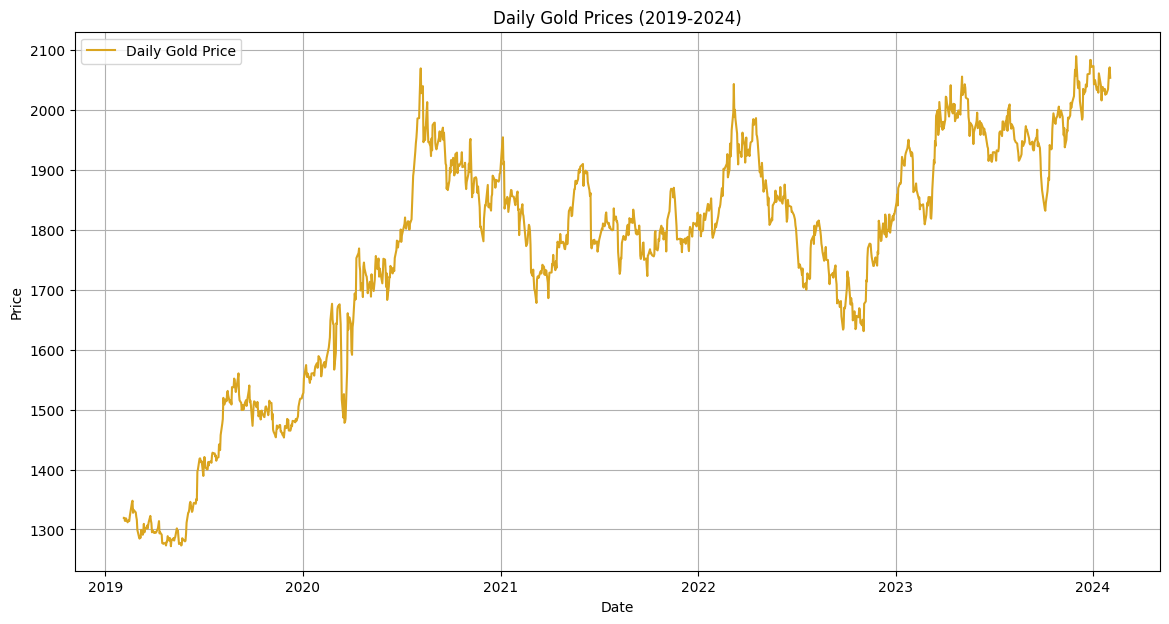

In [ ]:
#daily gold prices chart
Gold_Data['date'] = pd.to_datetime(Gold_Data['date'], format='%d-%m-%Y')
Gold_Data.set_index('date', inplace=True)
plt.figure(figsize=(14, 7))
plt.plot(Gold_Data['price'], label='Daily Gold Price', color='goldenrod')
plt.title('Daily Gold Prices (2019-2024)')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.grid(True)
plt.show()

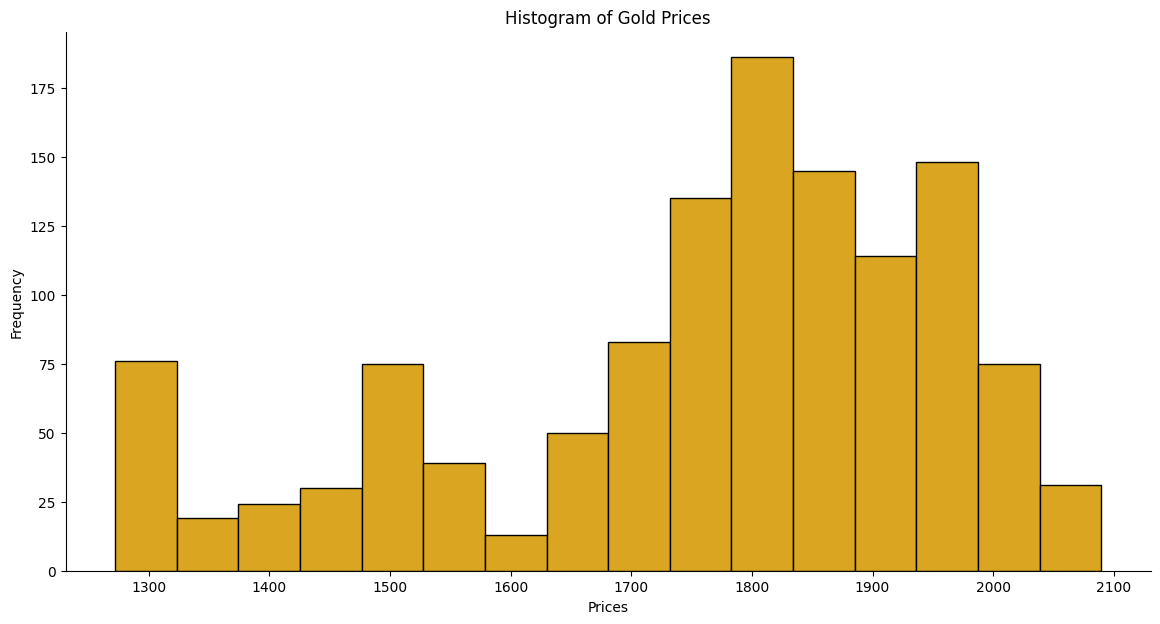

In [ ]:
#histogram of gold prices
plt.figure(figsize=(14, 7))
ax = Gold_Data['price'].plot(kind='hist', bins=16, color='goldenrod', edgecolor='black', title='Histogram of Gold Prices')
ax.set_xlabel('Prices')
plt.gca().spines[['top', 'right']].set_visible(False)
plt.show()

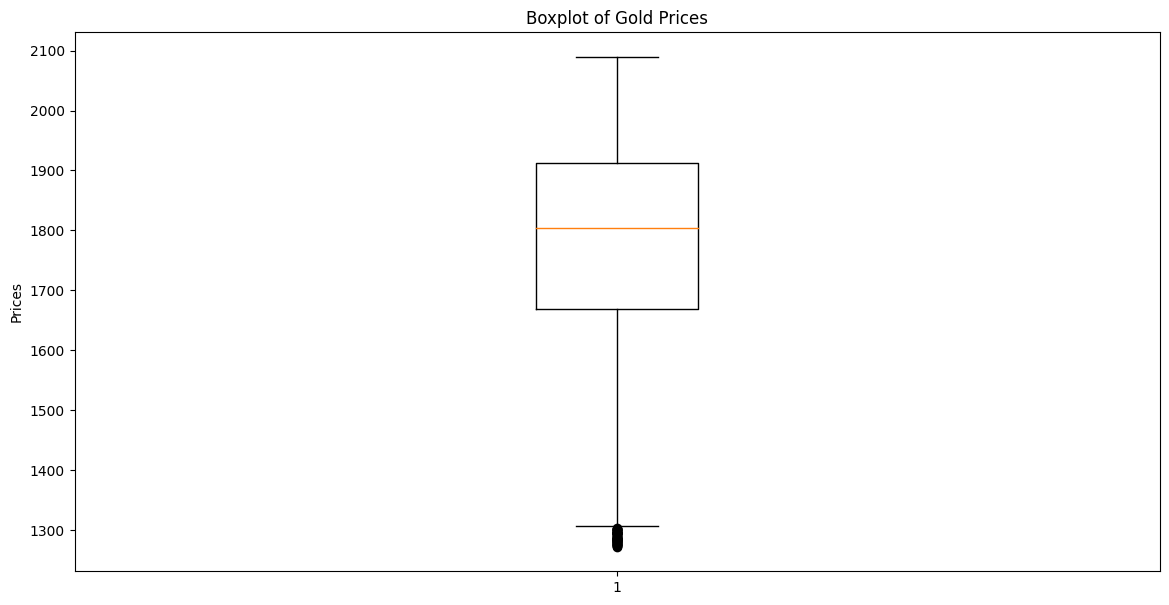

In [ ]:
#boxplot to identify outliers
plt.figure(figsize=(14, 7))
plt.boxplot(Gold_Data['price'])
plt.title('Boxplot of Gold Prices')
plt.ylabel('Prices')
plt.show()

In [ ]:
#finding the outliers

Q1 = Gold_Data['price'].quantile(0.25)
Q3 = Gold_Data['price'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = Gold_Data[(Gold_Data['price'] < lower_bound) | (Gold_Data['price'] > upper_bound)]

print("Outlier values:")
print(outliers[['date','price']])

Outlier values:
           date   price
1162 2019-05-30  1292.4
1163 2019-05-29  1281.0
1164 2019-05-28  1280.1
1165 2019-05-24  1283.6
1166 2019-05-23  1285.4
1167 2019-05-22  1274.2
1168 2019-05-21  1273.2
1169 2019-05-20  1277.3
1170 2019-05-17  1275.7
1171 2019-05-16  1286.2
1172 2019-05-15  1297.8
1173 2019-05-14  1296.3
1174 2019-05-13  1301.8
1175 2019-05-10  1287.4
1176 2019-05-09  1285.2
1177 2019-05-08  1281.4
1178 2019-05-07  1285.6
1179 2019-05-06  1283.8
1180 2019-05-03  1281.3
1181 2019-05-02  1272.0
1182 2019-05-01  1284.2
1183 2019-04-30  1285.7
1184 2019-04-29  1281.5
1185 2019-04-26  1288.8
1186 2019-04-25  1279.7
1187 2019-04-24  1279.4
1188 2019-04-23  1273.2
1189 2019-04-22  1277.6
1190 2019-04-18  1276.0
1191 2019-04-17  1276.8
1192 2019-04-16  1277.2
1193 2019-04-15  1291.3
1194 2019-04-12  1295.2
1195 2019-04-11  1293.3
1198 2019-04-08  1301.9
1199 2019-04-05  1295.6
1200 2019-04-04  1294.3
1201 2019-04-03  1295.3
1202 2019-04-02  1295.4
1203 2019-04-01  1294.2


##Second Data Set
This is dataset that contains the prices and market volume of 50 different cryptocoins in U.S. Dollars daily
starting from January 1, 2015. From this dataset, I will use the daily price data of Bitcoin (one of the most widespread cryptocurrencies) and FTX (a cryptocurrency that failed in 2022).

###Bitcoin Data

In [ ]:
filename = "bitcoin.csv"
Bitcoin_Data = pd.read_csv(join(path_prefix, filename))

#moving out the time from the date data and converting the dates to DD-MM-YYYY
Bitcoin_Data['date'] = pd.to_datetime(Bitcoin_Data['date']).dt.strftime('%d-%m-%Y')
#reverse the order of data to make it same with the gold data
Bitcoin_Data = Bitcoin_Data.iloc[::-1].reset_index(drop=True)

Bitcoin_Data.head()

,date,price,total_volume,market_cap,coin_name
0,27-03-2024,70082.051225,3.625732e+10,1.375729e+12,bitcoin
1,26-03-2024,69938.945302,4.482031e+10,1.371797e+12,bitcoin
2,25-03-2024,67310.983268,2.809832e+10,1.323456e+12,bitcoin
3,24-03-2024,64285.802791,2.548993e+10,1.264722e+12,bitcoin
4,23-03-2024,63509.044965,4.243660e+10,1.247366e+12,bitcoin


####Exploration and Description of the Data

In [ ]:
print(Bitcoin_Data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3373 entries, 0 to 3372
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   date          3373 non-null   object 
 1   price         3373 non-null   float64
 2   total_volume  3373 non-null   float64
 3   market_cap    3372 non-null   float64
 4   coin_name     3373 non-null   object 
dtypes: float64(3), object(2)
memory usage: 131.9+ KB
None


In [ ]:
print(Bitcoin_Data.describe())
Variance_Bitcoin = np.var(Bitcoin_Data['price'])
print(f"var    {Variance_Bitcoin:.2f}")

              price  total_volume    market_cap
count   3373.000000  3.373000e+03  3.372000e+03
mean   16010.058094  1.724184e+10  3.008013e+11
std    17194.074719  1.883256e+10  3.296922e+11
min      172.147900  1.823845e+07  2.362640e+09
25%     1280.986000  1.454057e+09  2.085192e+10
50%     8881.391704  1.237354e+10  1.583968e+11
75%    26848.239940  2.743276e+10  5.211950e+11
max    73097.767027  1.788941e+11  1.436631e+12
var    295548557.58


In [ ]:
#missing values of the Bitcoin data
missing_values = Bitcoin_Data.isnull().sum()
print("\nNumber of missing values:")
print(missing_values)
rows_with_missing_values = Bitcoin_Data[Bitcoin_Data.isnull().any(axis=1)]
print("\nDates of missing values:")
print(rows_with_missing_values)


Number of missing values:
date            0
price           0
total_volume    0
market_cap      1
coin_name       0
dtype: int64

Dates of missing values:
            date     price  total_volume  market_cap coin_name
2551  02-04-2017  1098.068  8.023151e+07         NaN   bitcoin


<ipython-input-20-ceb39eb77afc>:1: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  Bitcoin_Data['date'] = pd.to_datetime(Bitcoin_Data['date'])


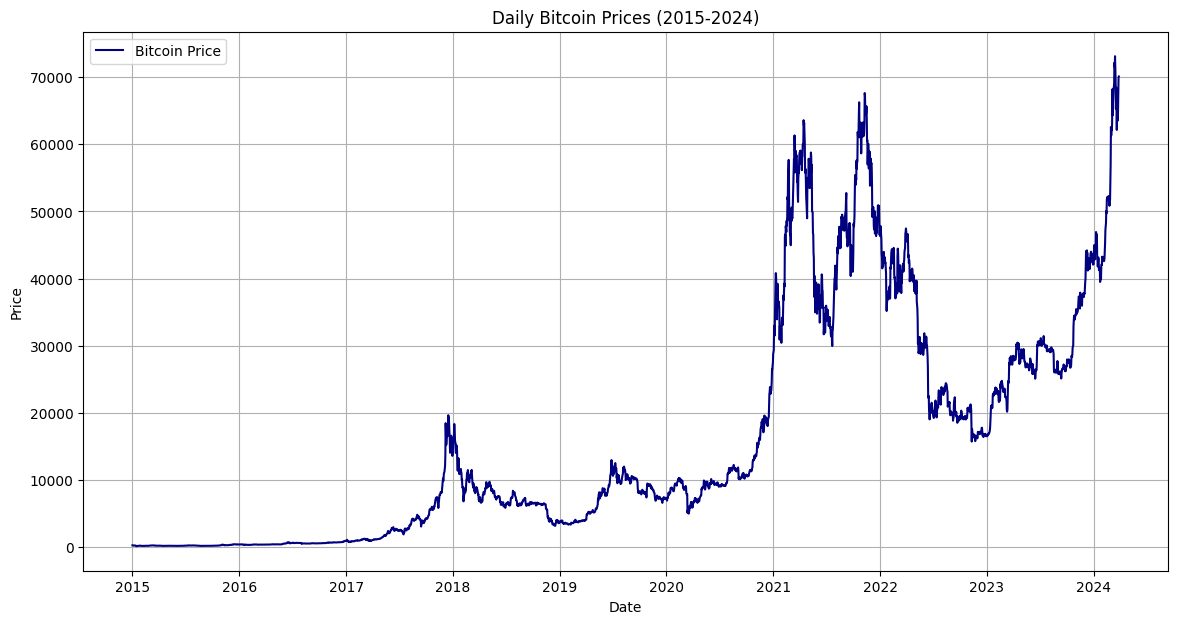

In [ ]:
Bitcoin_Data['date'] = pd.to_datetime(Bitcoin_Data['date'])
plt.figure(figsize=(14, 7))
plt.plot(Bitcoin_Data['date'], Bitcoin_Data['price'], label='Bitcoin Price', color='navy')
plt.title('Daily Bitcoin Prices (2015-2024)')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.grid(True)
plt.show()

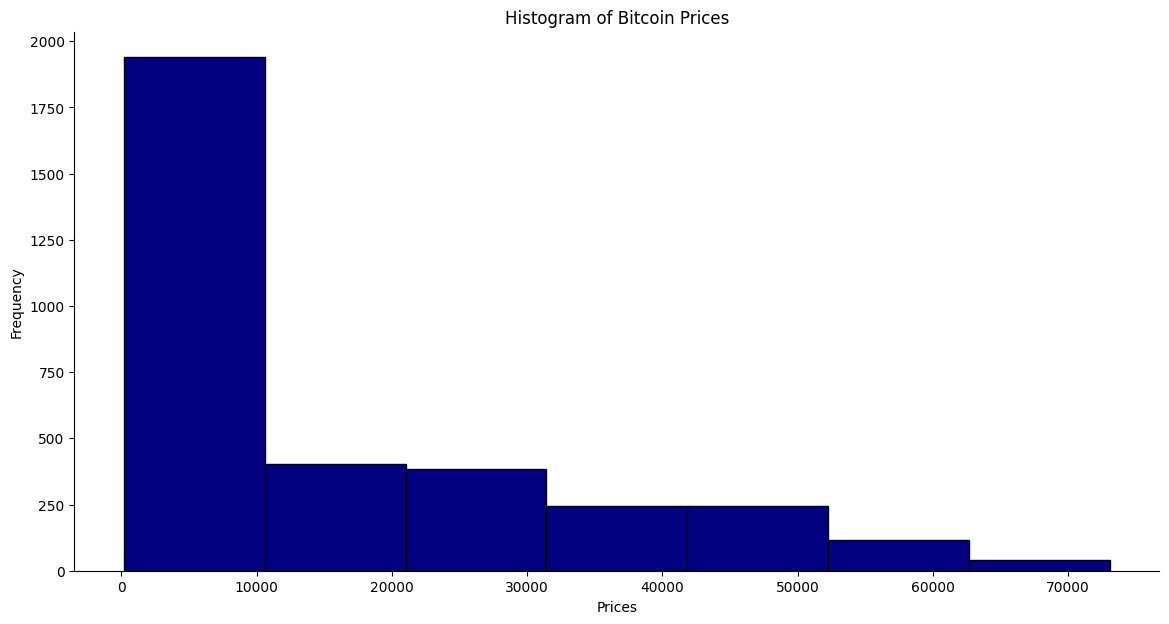

In [ ]:
#histogram
plt.figure(figsize=(14, 7))
ax = Bitcoin_Data['price'].plot(kind='hist', bins=7, color='navy', edgecolor='black', title='Histogram of Bitcoin Prices')
ax.set_xlabel('Prices')
plt.gca().spines[['top', 'right']].set_visible(False)
plt.show()

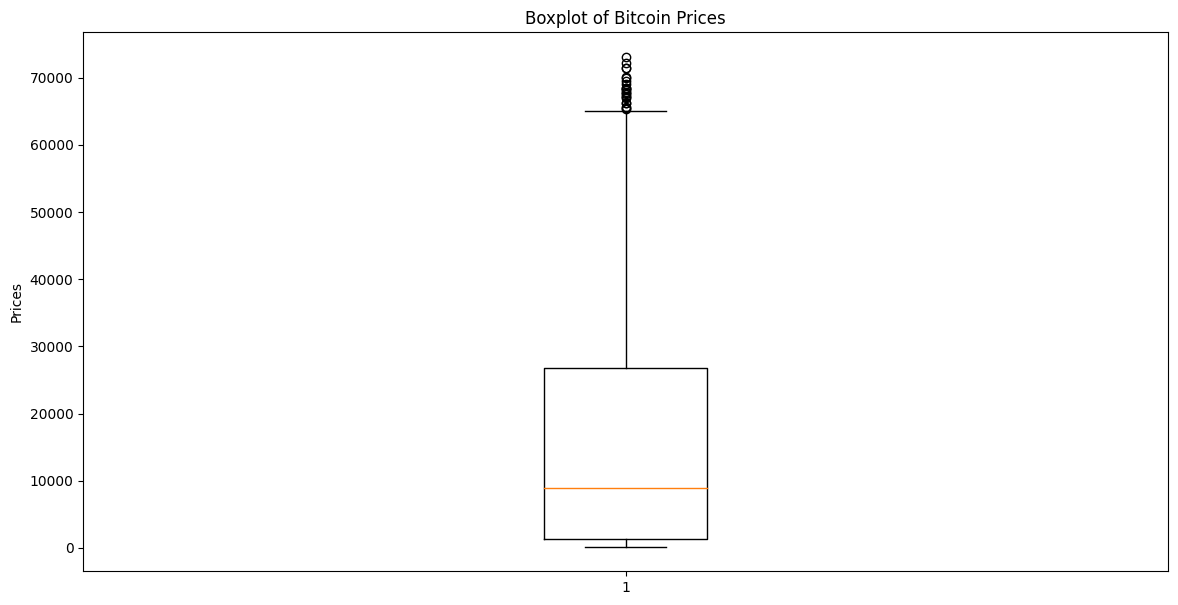

In [ ]:
#boxplot to identify outliers
plt.figure(figsize=(14, 7))
plt.boxplot(Bitcoin_Data['price'])
plt.title('Boxplot of Bitcoin Prices')
plt.ylabel('Prices')
plt.show()

In [ ]:
#the outlier values shown in the boxplot
Q1 = Bitcoin_Data['price'].quantile(0.25)
Q3 = Bitcoin_Data['price'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = Bitcoin_Data[(Bitcoin_Data['price'] < lower_bound) | (Bitcoin_Data['price'] > upper_bound)]

print("Outlier values:")
print(outliers[['date','price']])

Outlier values:
          date         price
0   2024-03-27  70082.051225
1   2024-03-26  69938.945302
2   2024-03-25  67310.983268
5   2024-03-22  65535.978448
6   2024-03-21  67819.055707
8   2024-03-19  67708.943609
9   2024-03-18  68425.415656
10  2024-03-17  65292.313293
11  2024-03-16  69497.763193
12  2024-03-15  71420.031801
13  2024-03-14  73097.767027
14  2024-03-13  71467.173503
15  2024-03-12  72130.553008
16  2024-03-11  69075.666882
17  2024-03-10  68508.003963
18  2024-03-09  68315.251921
19  2024-03-08  66944.876391
20  2024-03-07  66145.919279
22  2024-03-05  68186.645934
863 2021-11-15  65648.977791
868 2021-11-10  67145.374935
869 2021-11-09  67617.015545
888 2021-10-21  66237.517550


###FTX Data

In [ ]:
filename = "ftx-token.csv"
FTX_Data = pd.read_csv(join(path_prefix, filename))


#moving out the time from the date data and converting the dates to DD-MM-YYYY
FTX_Data['date'] = pd.to_datetime(FTX_Data['date']).dt.strftime('%d-%m-%Y')
#reverse the order of data to make it same with the gold data
FTX_Data = FTX_Data.iloc[::-1].reset_index(drop=True)

FTX_Data.head()

,date,price,total_volume,market_cap,coin_name
0,27-03-2024,2.131384,2.699810e+07,0.0,ftx-token
1,26-03-2024,2.180861,4.993340e+07,0.0,ftx-token
2,25-03-2024,2.092703,3.669957e+07,0.0,ftx-token
3,24-03-2024,2.085960,4.517822e+07,0.0,ftx-token
4,23-03-2024,1.927430,3.658041e+07,0.0,ftx-token


On Nov. 11, 2022, FTX filed for bankruptcy. We are trimming the data set from that point onwards.

In [ ]:
#trim the data from 11-11-2022 onwards

FTX_Data['date'] = pd.to_datetime(FTX_Data['date'], format='%d-%m-%Y')
FTX_Data = FTX_Data[FTX_Data['date'] <= '2022-11-11']
FTX_Data['date'] = FTX_Data['date'].dt.strftime('%d-%m-%Y')

FTX_Data.head()

<ipython-input-15-ae9405451b6c>:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  FTX_Data['date'] = FTX_Data['date'].dt.strftime('%d-%m-%Y')


,date,price,total_volume,market_cap,coin_name
502,11-11-2022,3.511902,1.369223e+09,4.654236e+08,ftx-token
503,10-11-2022,2.203681,2.083663e+09,2.969627e+08,ftx-token
504,09-11-2022,5.472950,4.369279e+09,7.481822e+08,ftx-token
505,08-11-2022,22.078314,1.263647e+09,2.936533e+09,ftx-token
506,07-11-2022,22.268173,1.681208e+09,2.979359e+09,ftx-token


####Exploration and Description of the Data

In [ ]:
print(FTX_Data.info())

<class 'pandas.core.frame.DataFrame'>
Index: 1201 entries, 502 to 1702
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   date          1201 non-null   object 
 1   price         1201 non-null   float64
 2   total_volume  1201 non-null   float64
 3   market_cap    1201 non-null   float64
 4   coin_name     1201 non-null   object 
dtypes: float64(3), object(2)
memory usage: 56.3+ KB
None


In [ ]:
print(FTX_Data.describe())
Variance_FTX = np.var(FTX_Data['price'])
print(f"var      {Variance_FTX:.5f}")

             price  total_volume    market_cap
count  1201.000000  1.201000e+03  1.201000e+03
mean     22.181209  1.035995e+08  2.594787e+09
std      20.012629  2.754740e+08  2.510151e+09
min       1.149703  7.635625e+05  0.000000e+00
25%       2.915705  4.764355e+06  2.904210e+08
50%      23.885833  3.821974e+07  2.571239e+09
75%      39.772614  9.692412e+07  4.612007e+09
max      80.486345  4.369279e+09  9.756571e+09
var      400.17184


In [ ]:
#missing values of the FTX data
missing_values = FTX_Data.isnull().sum()
print("\nNumber of missing values:")
print(missing_values)
rows_with_missing_values = FTX_Data[FTX_Data.isnull().any(axis=1)]
print("\nDates of missing values:")
print(rows_with_missing_values)


Number of missing values:
date            0
price           0
total_volume    0
market_cap      0
coin_name       0
dtype: int64

Dates of missing values:
Empty DataFrame
Columns: [date, price, total_volume, market_cap, coin_name]
Index: []


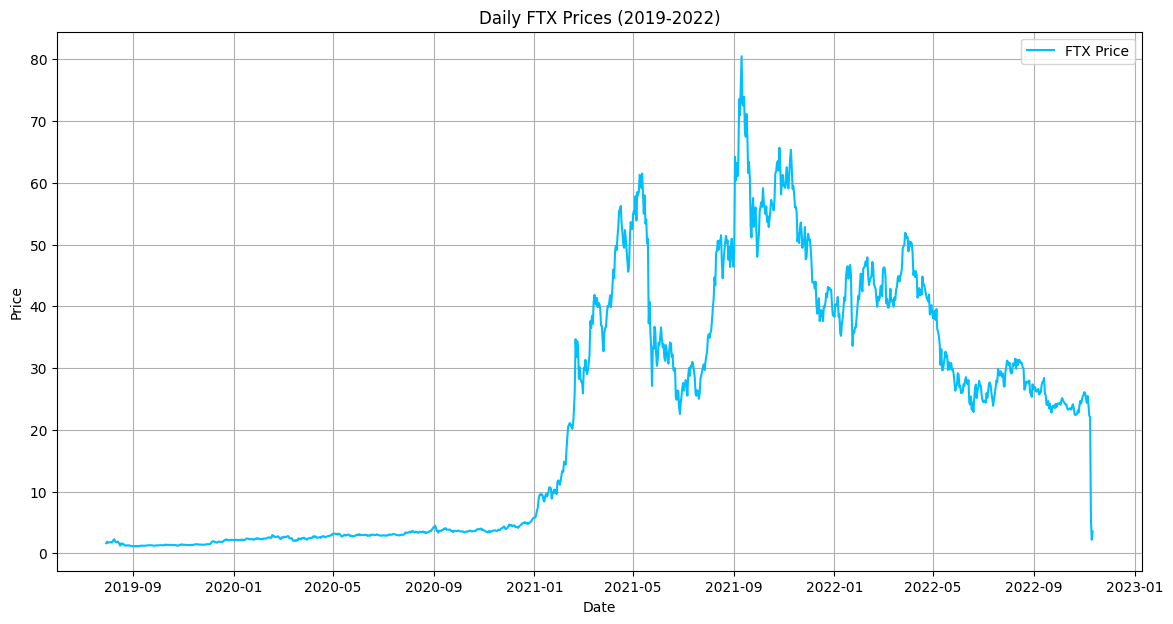

In [ ]:
FTX_Data['date'] = pd.to_datetime(FTX_Data['date'], format='%d-%m-%Y')
plt.figure(figsize=(14, 7))
plt.plot(FTX_Data['date'], FTX_Data['price'], label='FTX Price', color='deepskyblue')
plt.title('Daily FTX Prices (2019-2022)')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.grid(True)
plt.show()

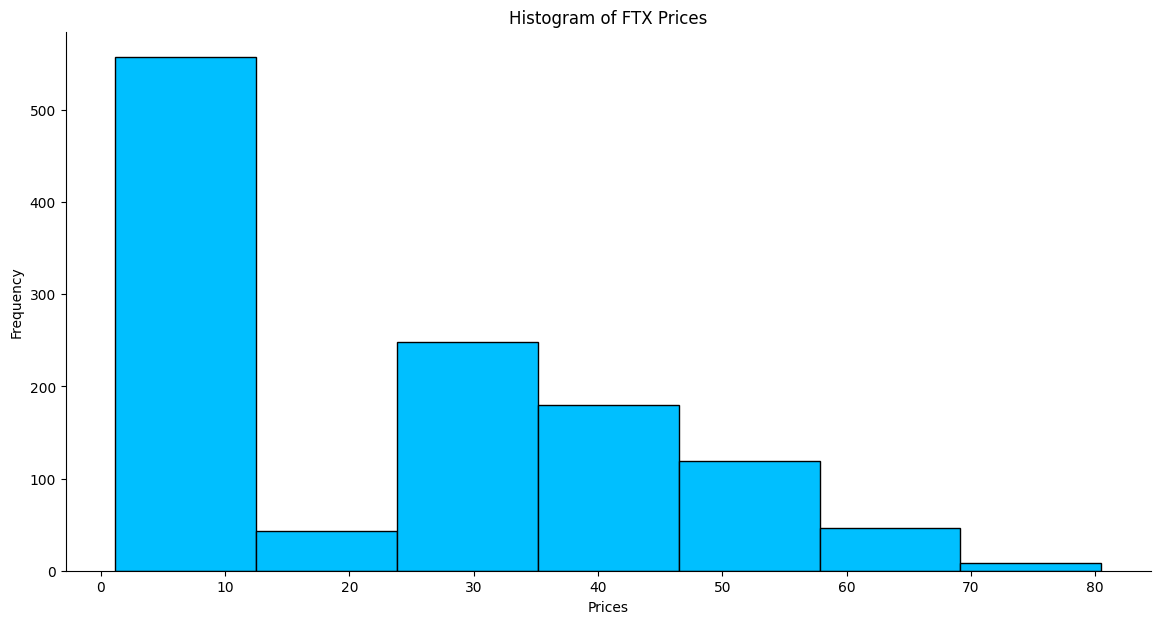

In [ ]:
#histogram
plt.figure(figsize=(14, 7))
ax = FTX_Data['price'].plot(kind='hist', bins=7, color='deepskyblue', edgecolor='black', title='Histogram of FTX Prices')
ax.set_xlabel('Prices')
plt.gca().spines[['top', 'right']].set_visible(False)
plt.show()

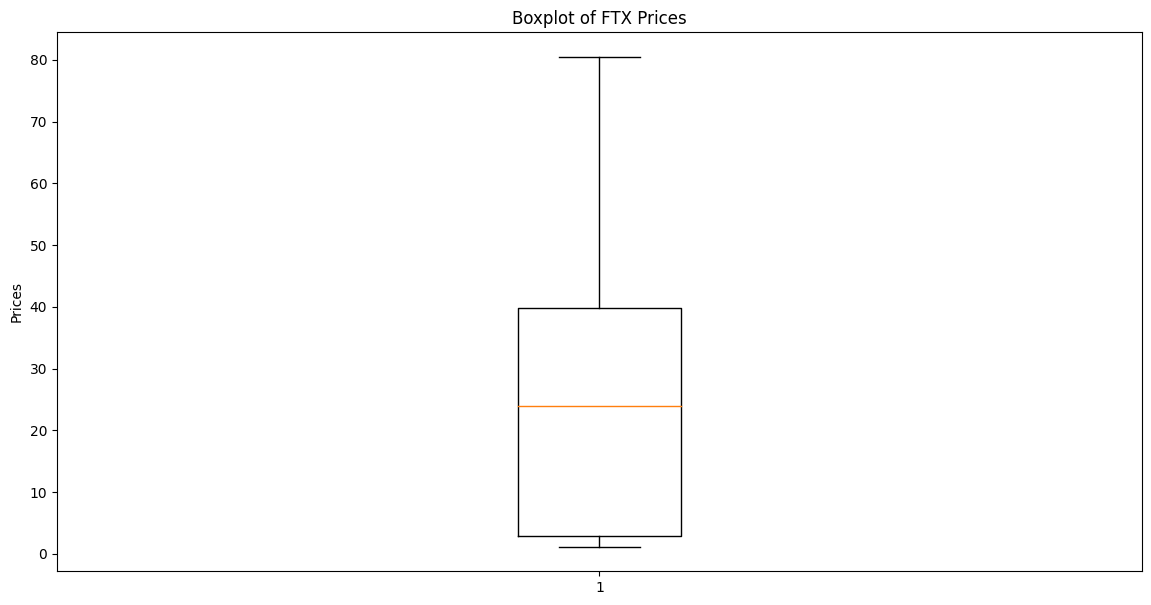

In [ ]:
#boxplot
plt.figure(figsize=(14, 7))
plt.boxplot(FTX_Data['price'])
plt.title('Boxplot of FTX Prices')
plt.ylabel('Prices')
plt.show()

In [ ]:
#outliers
Q1 = FTX_Data['price'].quantile(0.25)
Q3 = FTX_Data['price'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = FTX_Data[(FTX_Data['price'] < lower_bound) | (FTX_Data['price'] > upper_bound)]

print("Outliers values:")
print(outliers[['date','price']])

Outliers values:
Empty DataFrame
Columns: [date, price]
Index: []


##Data Comparision

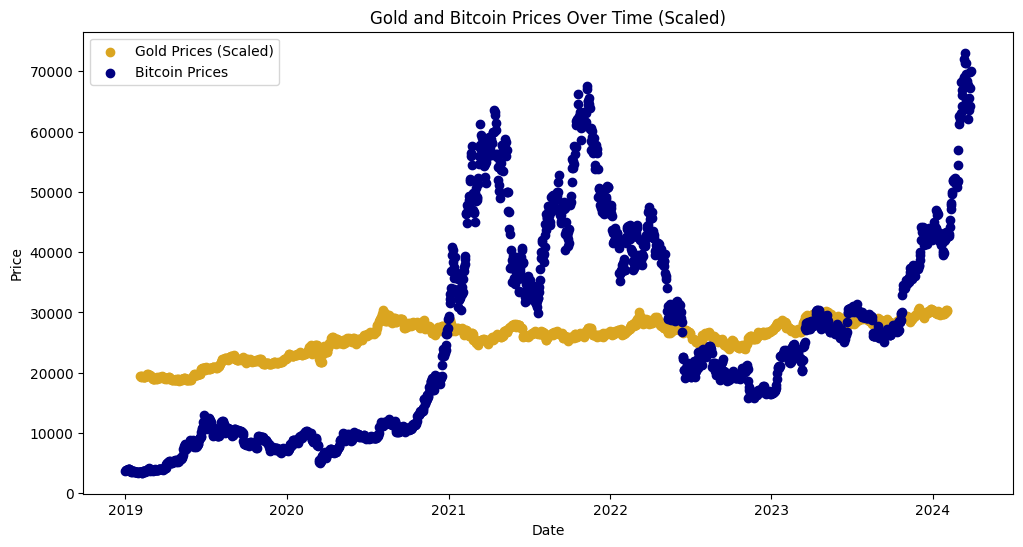

In [ ]:
Gold_Data['date'] = pd.to_datetime(Gold_Data['date'], format='%d-%m-%Y')
Bitcoin_Data['date'] = pd.to_datetime(Bitcoin_Data['date'])

#scaling the gold data to obtain a better scatterplot
mean_gold = Gold_Data['price'].mean()
mean_bitcoin = Bitcoin_Data['price'].mean()
scaling_factor = mean_bitcoin / mean_gold
Gold_Data['scaled_price'] = Gold_Data['price'] * scaling_factor

#trimming the bitcoin data for it to start from 2019
Bitcoin_Data = Bitcoin_Data[Bitcoin_Data['date'] >= '2019-01-01']
Gold_Data = Gold_Data[Gold_Data['date'] >= '2019-01-01']

plt.figure(figsize=(12, 6))


plt.scatter(Gold_Data['date'], Gold_Data['scaled_price'], color='goldenrod', label='Gold Prices (Scaled)')
plt.scatter(Bitcoin_Data['date'], Bitcoin_Data['price'], color='navy', label='Bitcoin Prices')
plt.xlabel('Date')
plt.ylabel('Price')
plt.title('Gold and Bitcoin Prices Over Time (Scaled)')
plt.legend()
plt.show()

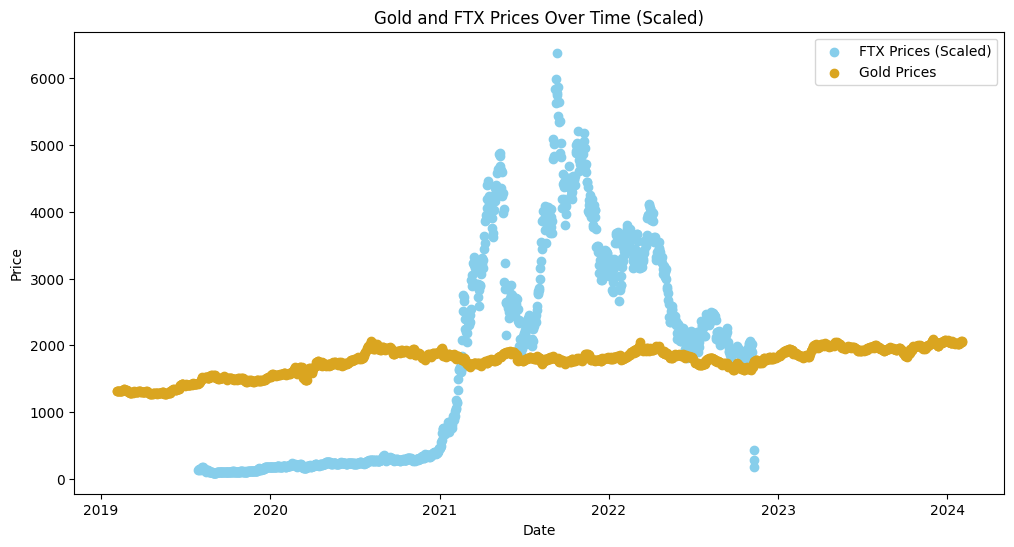

In [ ]:
Gold_Data['date'] = pd.to_datetime(Gold_Data['date'], format='%d-%m-%Y')
FTX_Data['date'] = pd.to_datetime(FTX_Data['date'])

#scaling the FTX data to obtain a better scatterplot
mean_ftx = FTX_Data['price'].mean()
mean_gold = Gold_Data['price'].mean()
scaling_factor = mean_gold / mean_ftx
FTX_Data['scaled_price'] = FTX_Data['price'] * scaling_factor

plt.figure(figsize=(12, 6))
plt.scatter(FTX_Data['date'], FTX_Data['scaled_price'], color='skyblue', label='FTX Prices (Scaled)')
plt.scatter(Gold_Data['date'], Gold_Data['price'], color='goldenrod', label='Gold Prices')
plt.xlabel('Date')
plt.ylabel('Price')
plt.title('Gold and FTX Prices Over Time (Scaled)')
plt.legend()
plt.show()

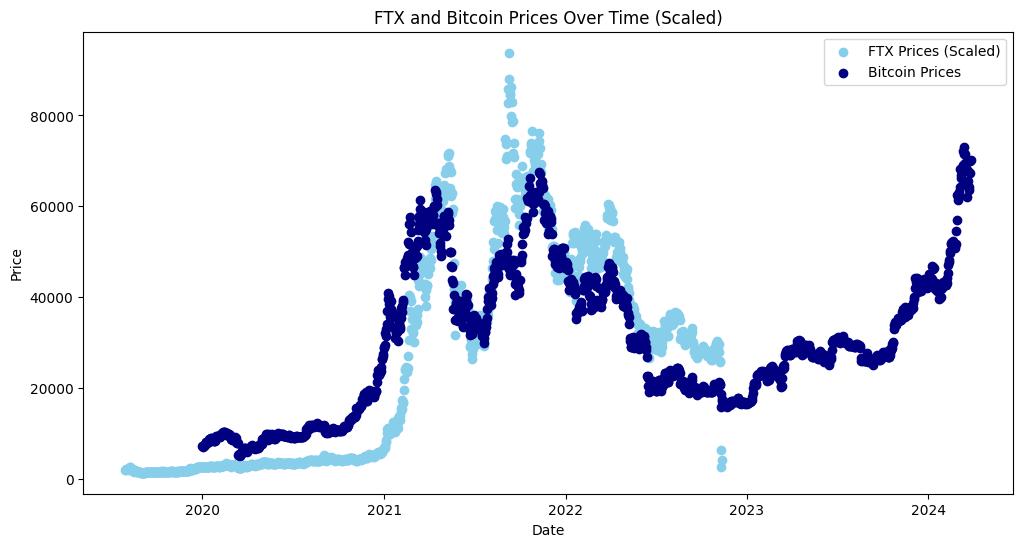

In [ ]:
Bitcoin_Data['date'] = pd.to_datetime(Bitcoin_Data['date'])
FTX_Data['date'] = pd.to_datetime(FTX_Data['date'])

#scaling the FTX data to obtain a better scatterplot
mean_ftx = FTX_Data['price'].mean()
mean_bitcoin = Bitcoin_Data['price'].mean()
scaling_factor = mean_bitcoin / mean_ftx
FTX_Data['scaled_price'] = FTX_Data['price'] * scaling_factor

Bitcoin_Data = Bitcoin_Data[Bitcoin_Data['date'] >= '2020-01-01']

plt.figure(figsize=(12, 6))
plt.scatter(FTX_Data['date'], FTX_Data['scaled_price'], color='skyblue', label='FTX Prices (Scaled)')
plt.scatter(Bitcoin_Data['date'], Bitcoin_Data['price'], color='navy', label='Bitcoin Prices')
plt.xlabel('Date')
plt.ylabel('Price')
plt.title('FTX and Bitcoin Prices Over Time (Scaled)')
plt.legend()
plt.show()

##Hypothesis Testing

**H0: There is not a significant correlation between gold prices and cryptocurrency prices.**

**H1: There is significant correlation between gold prices and cryptocurrency prices.**

###Testing for Bitcoin

In [ ]:
#merge the datasets
merged_data_btc = pd.merge(Gold_Data, Bitcoin_Data, on='date', how='inner')
merged_data_btc.rename(columns={'price_x': 'gold_price_btc', 'price_y': 'bitcoin_price'}, inplace=True)
merged_data_btc.head()

,date,gold_price_btc,Gold_Vol.,bitcoin_price,total_volume,market_cap,coin_name
0,02-02-2024,2053.7,NaN,43069.043421,2.244368e+10,8.445852e+11,bitcoin
1,01-02-2024,2071.1,260920.0,42583.263547,2.219794e+10,8.354214e+11,bitcoin
2,31-01-2024,2067.4,238370.0,42892.034530,2.452666e+10,8.392941e+11,bitcoin
3,30-01-2024,2050.9,214590.0,43267.609276,2.068032e+10,8.491990e+11,bitcoin
4,29-01-2024,2034.9,1780.0,42026.578562,1.366991e+10,8.242401e+11,bitcoin


In [ ]:
from scipy.stats import pearsonr

gold_price_btc = merged_data_btc['gold_price_btc']
bitcoin_price = merged_data_btc['bitcoin_price']

#calculating correlation coefficent and p value
corr_coefficient, p_value = pearsonr(gold_price_btc, bitcoin_price)
print("Correlation Coefficient:", corr_coefficient)
print("P-value:", p_value)

Correlation Coefficient: 0.5382272912425552
P-value: 2.7997095262405186e-94


The Correlation Coefficent suggests a moderate positive correlation between Bitcoin prices and gold prices.

P-value is smaller than the significance level of 0.05, so we reject the null hypothesis.

We conclude that there is a significant correlation between Bitcoin and gold prices.

###Testing for FTX

In [ ]:
#merge the datasets
merged_data_ftx = pd.merge(Gold_Data, FTX_Data, on='date', how='inner')
merged_data_ftx.rename(columns={'price_x': 'gold_price_ftx', 'price_y': 'ftx_price'}, inplace=True)
merged_data_ftx.head()



,date,gold_price_ftx,Gold_Vol.,ftx_price,total_volume,market_cap,coin_name
0,11-11-2022,1769.4,227040.0,3.511902,1.369223e+09,4.654236e+08,ftx-token
1,10-11-2022,1753.7,305720.0,2.203681,2.083663e+09,2.969627e+08,ftx-token
2,09-11-2022,1713.7,239650.0,5.472950,4.369279e+09,7.481822e+08,ftx-token
3,08-11-2022,1716.0,297620.0,22.078314,1.263647e+09,2.936533e+09,ftx-token
4,07-11-2022,1680.5,187590.0,22.268173,1.681208e+09,2.979359e+09,ftx-token


In [ ]:
gold_price_ftx = merged_data_ftx['gold_price_ftx']
ftx_price = merged_data_ftx['ftx_price']

#calculate correlation coefficient and p-value
corr_coefficient, p_value = pearsonr(gold_price_ftx, ftx_price)
print("Correlation Coefficient:", corr_coefficient)
print("P-value:", p_value)

Correlation Coefficient: 0.3904176269005823
P-value: 4.5345939501436455e-31


The Correlation Coefficent of suggests a moderate positive correlation between FTX prices and gold prices.

P-value is smaller than the significance level of 0.05, so we reject the null hypothesis.

We conclude that there is a significant correlation between FTX and gold prices.

###Hypothesis Conclusions
We found out that both Bitcoin and FTX prices have a correlation with gold prices so we conclude that there is a correlation between gold prices and cryptocurrencies

##Linear Regression Model

In [ ]:
import statsmodels.api as sm

#adding a constant to the independent variable (gold price)
X = sm.add_constant(merged_data_btc['gold_price_btc'])

#dependent variable (bitcoin price)
y = merged_data_btc['bitcoin_price']

model = sm.OLS(y, X)
results = model.fit()
print(results.summary())

                            OLS Regression Results                            
Dep. Variable:          bitcoin_price   R-squared:                       0.290
Model:                            OLS   Adj. R-squared:                  0.289
Method:                 Least Squares   F-statistic:                     506.1
Date:                Wed, 22 May 2024   Prob (F-statistic):           2.80e-94
Time:                        09:51:43   Log-Likelihood:                -13588.
No. Observations:                1243   AIC:                         2.718e+04
Df Residuals:                    1241   BIC:                         2.719e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const          -4.958e+04   3347.889    -14.

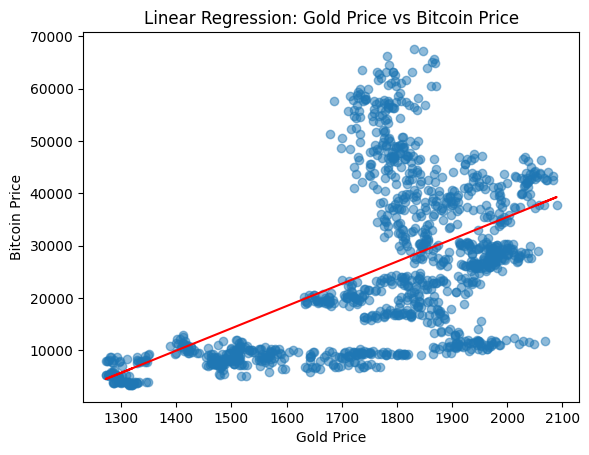

In [ ]:
plt.scatter(merged_data_btc['gold_price_btc'], merged_data_btc['bitcoin_price'], alpha=0.5)

# Regression line
plt.plot(merged_data_btc['gold_price_btc'], results.fittedvalues, color='red')

plt.xlabel('Gold Price')
plt.ylabel('Bitcoin Price')
plt.title('Linear Regression: Gold Price vs Bitcoin Price')
plt.show()

##Machine Learning Algorithms

In [ ]:
merged_data_btc.head()

,date,gold_price_btc,Gold_Vol.,bitcoin_price,total_volume,market_cap,coin_name
0,02-02-2024,2053.7,NaN,43069.043421,2.244368e+10,8.445852e+11,bitcoin
1,01-02-2024,2071.1,260920.0,42583.263547,2.219794e+10,8.354214e+11,bitcoin
2,31-01-2024,2067.4,238370.0,42892.034530,2.452666e+10,8.392941e+11,bitcoin
3,30-01-2024,2050.9,214590.0,43267.609276,2.068032e+10,8.491990e+11,bitcoin
4,29-01-2024,2034.9,1780.0,42026.578562,1.366991e+10,8.242401e+11,bitcoin


###KNN Model

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error

X = merged_data_btc[['gold_price_btc']]
y = merged_data_btc['bitcoin_price']

#split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#initialize and train the KNN model
knn = KNeighborsRegressor(n_neighbors=5)
knn.fit(X_train, y_train)

#make predictions
y_pred_knn = knn.predict(X_test)

#evaluate the model
mse_knn = mean_squared_error(y_test, y_pred_knn)
print(f"KNN Mean Squared Error: {mse_knn}")
r2_knn = knn.score(X_test, y_test)
print(f"KNN R^2 Score: {r2_knn}")
rmse_knn = np.sqrt(mse_knn)
print(f"KNN Root Mean Squared Error: {rmse_knn}")



KNN Mean Squared Error: 166556357.28045318
KNN R^2 Score: 0.3663246163423488
KNN Root Mean Squared Error: 12905.671516060416


###Decision Tree Model

In [ ]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error

#initialize and train the Decision Tree model
dt = DecisionTreeRegressor(random_state=42)
dt.fit(X_train, y_train)

#make predictions
y_pred_dt = dt.predict(X_test)

#evaluate the model
mse_dt = mean_squared_error(y_test, y_pred_dt)
print(f"Decision Tree Mean Squared Error: {mse_dt}")
r2_dt = dt.score(X_test, y_test)
print(f"Decision Tree R^2 Score: {r2_dt}")
rmse_dt = np.sqrt(mse_dt)
print(f"Decision Tree Root Mean Squared Error: {rmse_dt}")


Decision Tree Mean Squared Error: 273383637.4310209
Decision Tree R^2 Score: -0.04010728958922294
Decision Tree Root Mean Squared Error: 16534.316962941677


###ML Conclusion

In [ ]:
from sklearn.model_selection import GridSearchCV

#define the parameter grid
param_grid_knn = {'n_neighbors': [3, 5, 7, 9, 11]}

#initialize KNN regressor
knn = KNeighborsRegressor()

#initialize GridSearchCV
grid_search_knn = GridSearchCV(estimator=knn, param_grid=param_grid_knn, cv=5, scoring='neg_mean_squared_error')

#fit the grid search to the data
grid_search_knn.fit(X_train, y_train)

#get the best parameters
best_params_knn = grid_search_knn.best_params_

#use the best parameters to train the KNN model
best_knn = KNeighborsRegressor(**best_params_knn)
best_knn.fit(X_train, y_train)

#make predictions
y_pred_knn_tuned = best_knn.predict(X_test)

#evaluate the tuned KNN model
mse_knn_tuned = mean_squared_error(y_test, y_pred_knn_tuned)
rmse_knn_tuned = np.sqrt(mse_knn_tuned)
r2_knn_tuned = best_knn.score(X_test, y_test)

print("Tuned KNN Model:")
print(f"Best Parameters: {best_params_knn}")
print(f"Tuned KNN Mean Squared Error: {mse_knn_tuned}")
print(f"Tuned KNN Root Mean Squared Error: {rmse_knn_tuned}")
print(f"Tuned KNN R^2 Score: {r2_knn_tuned}")


Tuned KNN Model:
Best Parameters: {'n_neighbors': 11}
Tuned KNN Mean Squared Error: 161911727.12786147
Tuned KNN Root Mean Squared Error: 12724.453902932788
Tuned KNN R^2 Score: 0.383995438651074


In [ ]:
#define the parameter grid
param_grid_dt = {'max_depth': [None, 5, 10, 15, 20]}

#initialize Decision Tree regressor
dt = DecisionTreeRegressor(random_state=42)

#initialize GridSearchCV
grid_search_dt = GridSearchCV(estimator=dt, param_grid=param_grid_dt, cv=5, scoring='neg_mean_squared_error')

#fit the grid search to the data
grid_search_dt.fit(X_train, y_train)

#get the best parameters
best_params_dt = grid_search_dt.best_params_

#use the best parameters to train the Decision Tree model
best_dt = DecisionTreeRegressor(**best_params_dt, random_state=42)
best_dt.fit(X_train, y_train)

#make predictions
y_pred_dt_tuned = best_dt.predict(X_test)

#evaluate the tuned Decision Tree model
mse_dt_tuned = mean_squared_error(y_test, y_pred_dt_tuned)
rmse_dt_tuned = np.sqrt(mse_dt_tuned)
r2_dt_tuned = best_dt.score(X_test, y_test)

print("Tuned Decision Tree Model:")
print(f"Best Parameters: {best_params_dt}")
print(f"Tuned Decision Tree Mean Squared Error: {mse_dt_tuned}")
print(f"Tuned Decision Tree Root Mean Squared Error: {rmse_dt_tuned}")
print(f"Tuned Decision Tree R^2 Score: {r2_dt_tuned}")


Tuned Decision Tree Model:
Best Parameters: {'max_depth': 5}
Tuned Decision Tree Mean Squared Error: 170094561.08215475
Tuned Decision Tree Root Mean Squared Error: 13042.030558243403
Tuned Decision Tree R^2 Score: 0.352863270956853


The KNN model outperforms the Decision Three Model in all three metrics as it has a lover MSE, lover RMSE and a higher R^2.